# **3　LSTMによる株価の予測**

　LSTMの理論を用い、本例では米セントルイス連銀から公開される日次為替レートのデータを用い、ドル円レートの予測値算出を行います。本節の実装において必要とされるライブラリは数値演算のためのnumpy、pandas、図表作成のためのmatplotlib、データ取得のためのpandas_datareader、データ正規化のためsklearnからMinMaxScaler、予測精度評価のためのr2_scoreをそれぞれインポートします。また、LSTMの実行に際し、kerasからLSTMの階層をセットアップするためのSequential、LSTM階層追加のためのLSTM、過学習の是正等に一定割合の算出値を除外するためのDropout、算出結果を結合するためのDenseを読み込みます。



In [ ]:
#[1]ライブラリの読み込み
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas_datareader as data
import datetime
from sklearn.preprocessing import MinMaxScaler #データ基準化のためのライブラリ
from sklearn.metrics import r2_score #予測精度検証のためのライブラリ
from keras.models import Sequential #LSTM階層構築のためのライブラリ
from keras.layers import LSTM #LSTM階層追加のためのライブラリ
from keras.layers import Dropout #過学習是正のためのライブラリ
from keras.layers import Dense #算出結果結合のためのライブラリ

　続いて日経平均株価を金融情報通信会社stooqからpandas_datareaderを用いて取得します。今回のケースでは2015年1月1日から2026年1月1日の日次データを取得します。stooqから取得する株価データは、始値、終値、売買高等、5種類のデータが含まれています。本節では終値のみを使用するため、新たに終値のみの時系列データであるデータフレームnikkeiを作成します。次にpandasデータフレームを.valuesをデータフレーム名の末尾に付けることにより、ndarray配列に変換します。このndarray配列のデータをMinMaxScaler()を用いて正規化し、そのデータをnikkei_scaledと命名します。

In [ ]:
#[2]株価の取得とデータの整理
df=data.DataReader('^NKX','stooq',start="2015-01-01",end="2026-01-01").sort_values(by='Date',ascending=True)
nikkei = df.filter(['Close'])
nikkei = nikkei.values #ndarray配列ヘの変換
scaler = MinMaxScaler(feature_range=(0,1))#データを0〜1の範囲に正規化
nikkei_scaled=scaler.fit_transform(nikkei)
nikkei_scaled

array([[0.06558288],
       [0.05155379],
       [0.05161092],
       ...,
       [0.9556599 ],
       [0.94969423],
       [0.9446904 ]])

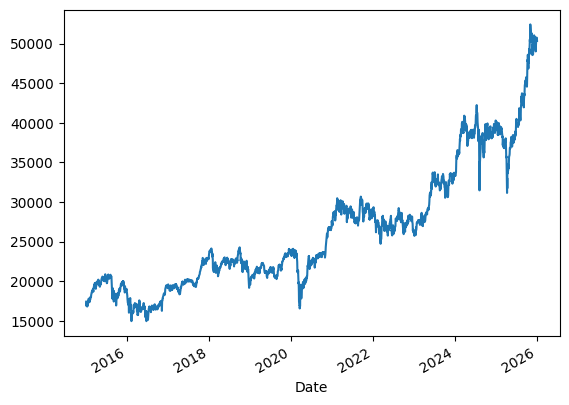

In [ ]:
df.Close.plot();

　続いてMinMaxScalerにより、0から1までのデータへ正規化されたデータnikkei_scaledを用い、訓練データを生成します。まず一行目では、全標本サンプルから70％のデータを用いることを定義づけします。続いく2行目では、時系列データの過去何日分のデータを用いて訓練データを作成するかを定義します。4～5行目では、ラグ付きデータの空配列x_train、ラグなしデータの空配列y_trainを設定し、6－8行目において、反復生成したデータをappendによりx_train、ラグなしデータの空配列y_trainに格納します。その後、このデータをndarray 3次元配列へ転換します。

In [ ]:
#[3]訓練データの生成と整理
nikkei_train_len = int(np.ceil(len(df) * .7 ))#訓練データの定義(本例は全サンプルの70％）
window_size = 60 #ラグ付きデータの長さの定義
nikkei_train = nikkei_scaled[0:int(nikkei_train_len), :]
x_train = [] #ラグ付きデータの空配列
y_train = [] #ラグなしデータの空配列
for i in range(window_size, len(nikkei_train)):#訓練データの生成と格納
    x_train.append(nikkei_train[i-window_size:i, 0])
    y_train.append(nikkei_train[i, 0])
x_train, y_train = np.array(x_train), np.array(y_train)#numpy配列へ変換
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))#配列次元数の変換

　次のセルでは、前セルで３次元配列に転換されたデータを用い、kerasを用いてLSTMモデルを構築します。まずmodel=Sequential()によりモデルの階層をセットアップし、続いて、model.addにより階層をひとつひとつ段階的に追加します。model=Sequential()によるモデルのセットアップ後は、LSTMのモデルが、どのような形式であるのかを指示する必要があします。このため、まずmodel.addによる２行目の最初の階層追加ではunits=によりユニットの数を指示し、shape=において入力する訓練データが３次元であることを指定します。またreturn_sequencesにより入力と出力の次元数が同じであることを併せて指示します。Dropoutを実行する階層では、この例では０．１とすることで、全階層の１０％が過学習是正など、算出データの正則化のため除外されます。

In [ ]:
#[4]LSTM階層の初期化・追加・ドロップアウト・調節の反復
model = Sequential() #モデル階層のセットアップ
model.add(LSTM(units=50,return_sequences=True,input_shape=(x_train.shape[1], 1))) #階層追加(ユニット数50、訓練データ次元数の定義)
model.add(Dropout(0.1)) #算出結果の10％を除外
model.add(LSTM(units=50,return_sequences=True))#階層追加と入出力の次元数継続を定義
model.add(Dropout(0.1)) #算出結果の10％を除外
model.add(LSTM(units=50,return_sequences=True))
model.add(Dropout(0.1)) #算出結果の10％を除外
model.add(LSTM(units=50))#階層追加
model.add(Dropout(0.1)) #算出結果の10％を除外
model.add(Dense(units=1))#階層追加
model.compile(optimizer='adam',loss='mean_squared_error') #パラメター学習最適化手法(adam)の設定
model.fit(x_train,y_train,epochs=50,batch_size=32) #フィッティング

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 16s 147ms/step - loss: 0.0114
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 123ms/step - loss: 8.9320e-04
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 144ms/step - loss: 9.1816e-04
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - loss: 7.4191e-04
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - loss: 6.7763e-04
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 134ms/step - loss: 6.6798e-04
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 5.6619e-04
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - loss: 5.8652e-04
Epoch 9/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - loss: 5.8737e-04
Epoch 10/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - loss: 6.1004e-04
Epoch 11/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - loss: 5.5251e-04
Epoch 12/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 8s 142ms/step - loss: 4.9628e-04
Epoch 13/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 4.9343e-04
Epoch 14/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 4.4643e-04
Ep

　セル[4]において、推計した実証モデルを用いて算出される予測値検証のための、テストデータを生成します。セル[5]の１行目では、訓練データの長さ（幅）からラグ・ウィンドウを差し引いた長さがテストデータの長さであることを定義します。空配列を設定した後、４～５行目において順次、テストデータを繰り返し計算し、x_testに格納します。このデータフレームは、ndarray配列に変換された後、訓練データ同様、３次元データに配列変換します。

In [ ]:
#[5]テストデータの生成と整理
nikkei_test = nikkei_scaled[nikkei_train_len - window_size: , :] #テストデータの定義
x_test = []
y_test = nikkei_scaled[nikkei_train_len:, :]
for i in range(window_size, len(nikkei_test)):#テストデータの生成と格納
    x_test.append(nikkei_test[i-window_size:i, 0])
x_test = np.array(x_test)#ndarray配列に変換
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

　次のセル[6]では、まずフィッティングにより得られた実証モデルを用い、テストデータx_testを用いて予測値を算出します。このテストデータから得られた予測値と、実績値を用い、二乗平均平方根誤差（RMSE）と決定係数（R2）から、予測結果の精度を確認します。RMSEは、算出結果がゼロに近いほど、予測値と実績値の間の誤差が小さいこと、すなわち予測精度が高いことを意味します。R2は１に近いほど、予測値と実績値が互いに重なり合っていることを示唆します。

In [ ]:
#[6]予測シミュレーションと検証
predictions = model.predict(x_test) #予測値の算出
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))#予測値とテストデータから二乗平均平方根誤差（RMSE）を算出
print(f'RMSE: {rmse:.5f}') #0に近い→予測値とテストデータの誤差が小さい(予測精度が高い)
r2_squared = r2_score(y_test, predictions)#予測値とテストデータから二乗平均平方根誤差（RMSE）を算出
print(f'R2: {r2_squared:.5f}') #1に近い→→予測値とテストデータの一致度が高い(予測精度が高い)

26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step
RMSE: 0.02396
R2: 0.97878


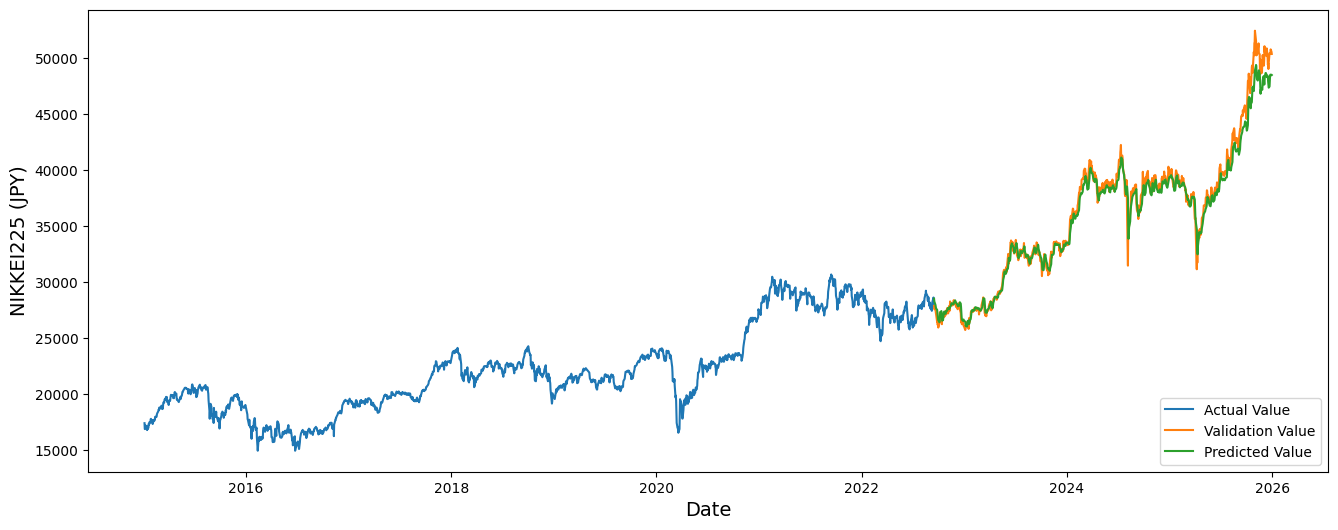

In [ ]:
#[7]予測結果と試算検証の可視化
predictions = scaler.inverse_transform(predictions) #正規化データを原数値へ変換
train_plot_nikkei = pd.DataFrame(df['Close'][:nikkei_train_len]) #実績期間の定義
valid_plot_nikkei = pd.DataFrame(df['Close'][nikkei_train_len:]) #検証期間の定義
valid_plot_nikkei['Predictions'] = predictions
plt.figure(figsize=(16,6))
plt.xlabel('Date', fontsize=14)
plt.ylabel('NIKKEI225 (JPY)', fontsize=14)
plt.plot(train_plot_nikkei['Close'], label='Actual Value')
plt.plot(valid_plot_nikkei['Close'], label='Validation Value')
plt.plot(valid_plot_nikkei['Predictions'], label='Predicted Value')
plt.legend(loc='lower right')
plt.show()

　テストデータと実績値を用いた検証の結果、本推計モデルのパフォーマンスが優れていることが確認できれば、最後に未来の株価予測を実行します。セル[8]一行目では、将来の予測期間を指定します。2026年1月1日までの実績データを用いている本例では、24カ月、2028年12月31日までの予測を行います。４～９行目では、２４カ月分の未来の予測値を逐次算出し、３行目で生成したfuture_predictionsと称する空配列に一つずつ格納します。最後に算出された予測値をscaler.inverse_transformにより原数値へ変換することで、2028年12月31日の株価予測値が得られます。

In [ ]:
#[8]未来の株価予測
future_dates = pd.date_range(start=df.index[-1], periods=24, freq='M') #データフレームdfから直近(最後の)データ日付の取得
future_data = nikkei_scaled[-window_size:].copy() #データフレームnikkei_scaledのコピーを作成
future_predictions = [] #予測結果格納のための空配列
for _ in range(len(future_dates)):
    future_input = future_data[-window_size:] #[3]で定義した現在から何日分のデータ使用かを再定義
    future_input = future_input.reshape((1, window_size, 1)) #データの整形
    future_pred = model.predict(future_input, verbose=0) #予測の実行
    future_data = np.append(future_data, future_pred, axis=0) #予測結果の配列への追加
    future_predictions.append(future_pred[0, 0]) #予測結果をリストに追加
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1)) #正規化された予測結果を原数値へ変換

/tmp/ipython-input-4161894832.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start=df.index[-1], periods=24, freq='M') #データフレームdfから直近(最後の)データ日付の取得


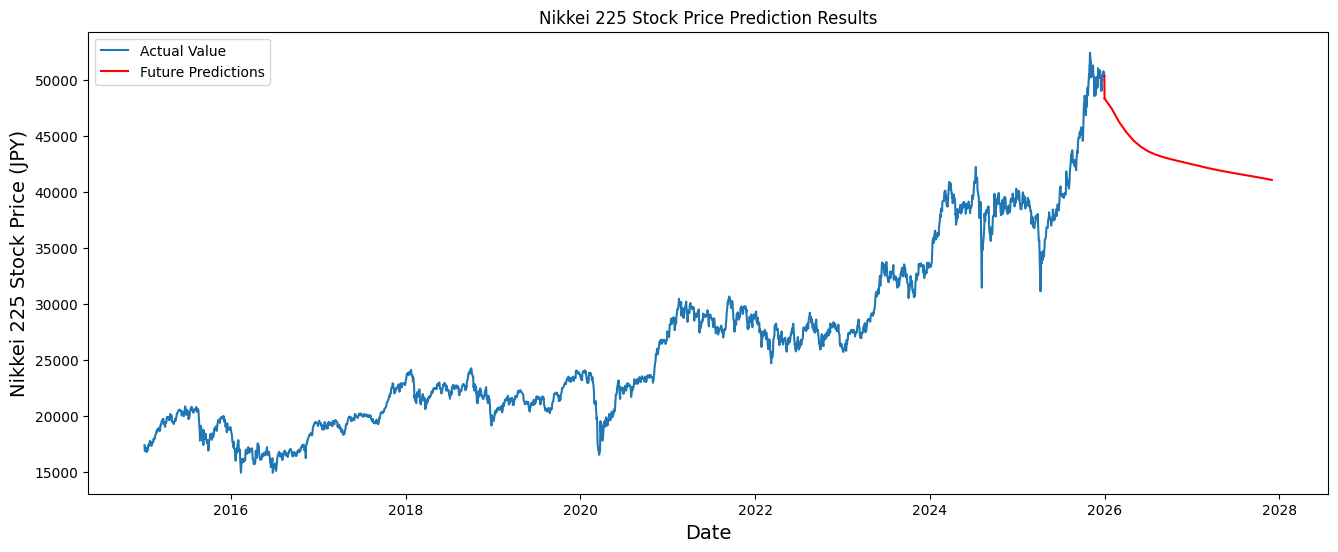

In [ ]:
#[9]株価予測結果の可視化
plt.figure(figsize=(16, 6))
plt.title('Nikkei 225 Stock Price Prediction Results')
plt.xlabel('Date', fontsize=14)
plt.ylabel('Nikkei 225 Stock Price (JPY)', fontsize=14)
plt.plot(df['Close'], label='Actual Value') #実績値のプロット
plt.plot([df.index[-1], future_dates[0]], [df['Close'].iloc[-1], future_predictions[0, 0]], color='red')
plt.plot(future_dates, future_predictions, color='red', label='Future Predictions') #予測結果のプロット
plt.legend(loc='upper left') #凡例場所のポジショニング設定
plt.show()

In [ ]:
#[10]株価予測結果のpandasデータフレームへの格納
nikkei225 = pd.DataFrame(data=future_predictions, index=future_dates, columns=['Predicted Value'])
nikkei225.head()

,Predicted Value
2025-12-31,48326.992188
2026-01-31,47387.523438
2026-02-28,46297.386719
2026-03-31,45348.906250
2026-04-30,44599.875000
